**This notebook is an exercise in the [Machine Learning Explainability](https://www.kaggle.com/learn/machine-learning-explainability) course.  You can reference the tutorial at [this link](https://www.kaggle.com/dansbecker/partial-plots).**

---


## Set Up

Today you will create partial dependence plots and practice building insights with data from the [Taxi Fare Prediction](https://www.kaggle.com/c/new-york-city-taxi-fare-prediction) competition.

We have again provided code to do the basic loading, review and model-building. Run the cell below to set everything up:

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print("Setup Complete")

# Data manipulation code below here
data = pd.read_csv('train.csv', nrows=50000)

# Remove data with extreme outlier coordinates or negative fares
data = data.query('pickup_latitude > 40.7 and pickup_latitude < 40.8 and ' +
                  'dropoff_latitude > 40.7 and dropoff_latitude < 40.8 and ' +
                  'pickup_longitude > -74 and pickup_longitude < -73.9 and ' +
                  'dropoff_longitude > -74 and dropoff_longitude < -73.9 and ' +
                  'fare_amount > 0'
                  )

y = data.fare_amount

base_features = ['pickup_longitude',
                 'pickup_latitude',
                 'dropoff_longitude',
                 'dropoff_latitude']

X = data[base_features]


train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
first_model = RandomForestRegressor(n_estimators=30, random_state=1).fit(train_X, train_y)
print("Data sample:")
data.head()

Setup Complete
Data sample:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-01 00:00:00.0000001,3.508282,2015-01-01 12:00:00 UTC,-73.960636,40.737454,-73.967156,40.722575,1
1,2015-01-01 00:01:00.0000001,3.236949,2015-01-01 12:00:00 UTC,-73.952656,40.795071,-73.953657,40.783820,2
3,2015-01-01 00:03:00.0000001,2.890130,2015-01-01 12:00:00 UTC,-73.966000,40.759866,-73.960912,40.748127,5
4,2015-01-01 00:04:00.0000001,4.906474,2015-01-01 12:00:00 UTC,-73.913035,40.715602,-73.929318,40.726728,4
6,2015-01-01 00:06:00.0000001,3.098649,2015-01-01 12:00:00 UTC,-73.922320,40.705808,-73.922963,40.706664,4


In [3]:
data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,4251.000000,4251.000000,4251.000000,4251.000000,4251.000000,4251.000000
mean,3.783340,-73.950823,40.749844,-73.950492,40.749875,2.989414
std,1.043287,0.026756,0.027399,0.026900,0.027151,1.401220
min,2.500000,-73.999960,40.700001,-73.999997,40.700019,1.000000
25%,2.859901,-73.973416,40.726750,-73.973249,40.726593,2.000000
50%,3.664892,-73.951352,40.750264,-73.951245,40.750806,3.000000
75%,4.477440,-73.928503,40.772991,-73.927914,40.772757,4.000000
max,8.370755,-73.900065,40.799972,-73.900008,40.799998,5.000000


## Question 1

Here is the code to plot the partial dependence plot for `pickup_longitude`.  Run the following cell without changes.

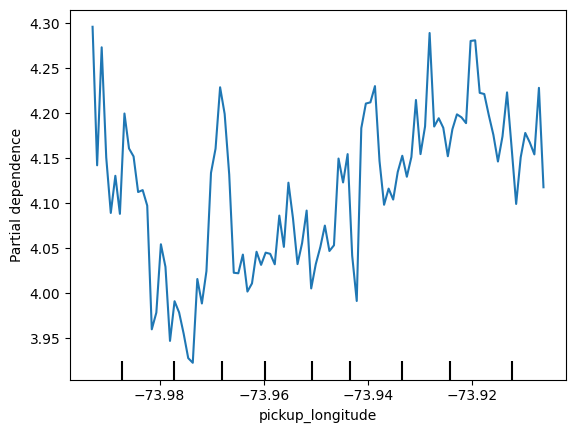

In [4]:
from matplotlib import pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

feat_name = 'pickup_longitude'
PartialDependenceDisplay.from_estimator(first_model, val_X, [feat_name])
plt.show()

Why does the partial dependence plot have this U-shape?

Does your explanation suggest what shape to expect in the partial dependence plots for the other features?

Create all other partial plots in a for-loop below (copying the appropriate lines from the code above).

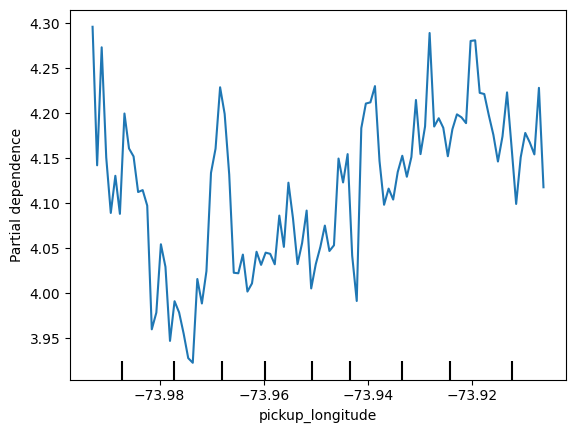

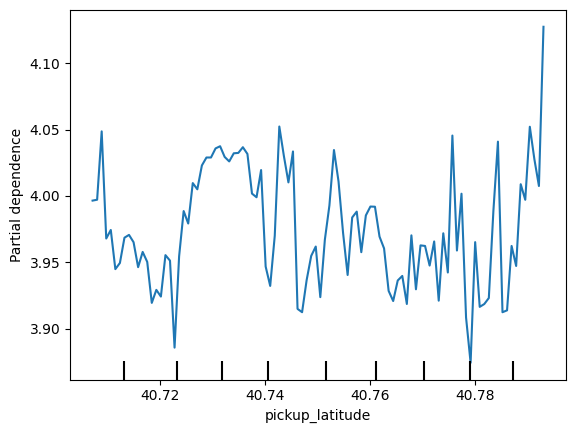

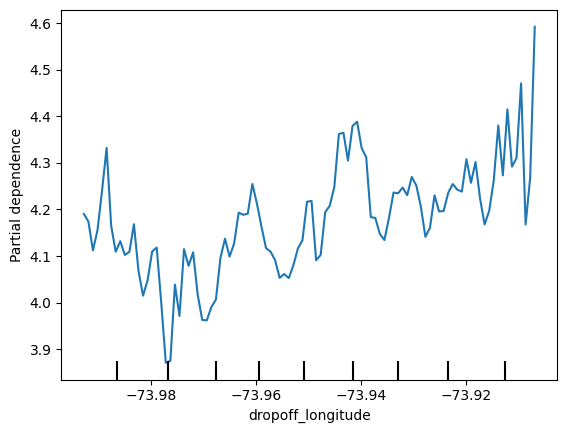

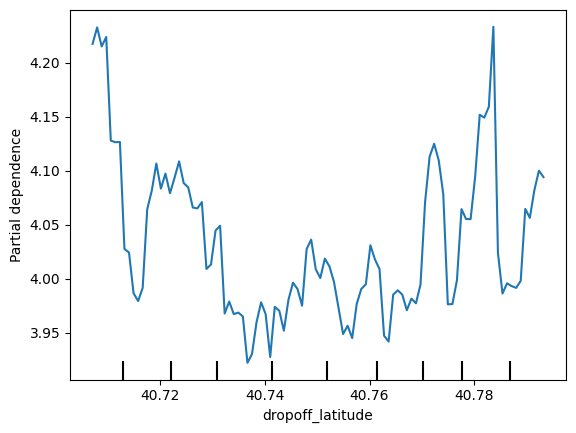

In [5]:
for feat_name in base_features:
    PartialDependenceDisplay.from_estimator(first_model, val_X, [feat_name])
    plt.show()

Do the shapes match your expectations for what shapes they would have? Can you explain the shape now that you've seen them? 

Uncomment the following line to check your intuition.

## Question 2

Now you will run a 2D partial dependence plot.  As a reminder, here is the code from the tutorial.  

```
fig, ax = plt.subplots(figsize=(8, 6))
f_names = [('Goal Scored', 'Distance Covered (Kms)')]
PartialDependenceDisplay.from_estimator(tree_model, val_X, f_names, ax=ax)
plt.show()
```

Create a 2D plot for the features `pickup_longitude` and `dropoff_longitude`.

What do you expect it to look like?

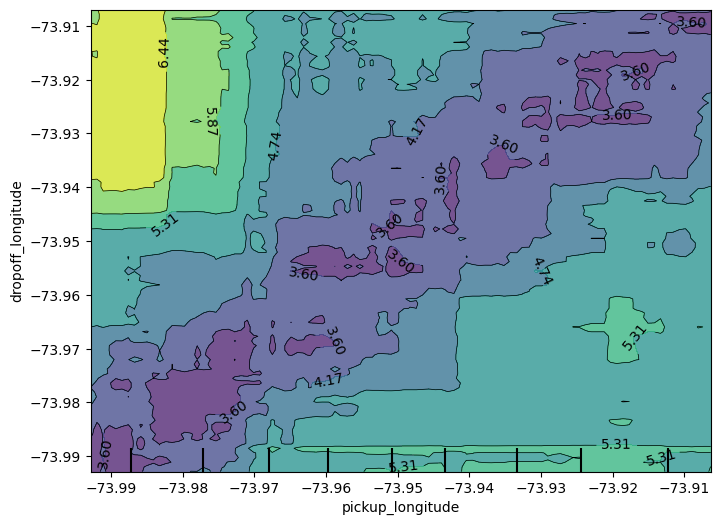

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
fnames = [('pickup_longitude', 'dropoff_longitude')]
disp = PartialDependenceDisplay.from_estimator(first_model, val_X, fnames, ax=ax)
plt.show()

Uncomment the line below to see the solution and explanation for how one might reason about the plot shape.

For a solution or hint, uncomment the appropriate line below.

## Question 4
In the PDP's you've seen so far, location features have primarily served as a proxy to capture distance traveled. In the permutation importance lessons, you added the features `abs_lon_change` and `abs_lat_change` as a more direct measure of distance.

Create these features again here. You only need to fill in the top two lines.  Then run the following cell.  

**After you run it, identify the most important difference between this partial dependence plot and the one you got without absolute value features. The code to generate the PDP without absolute value features is at the top of this code cell.**

---

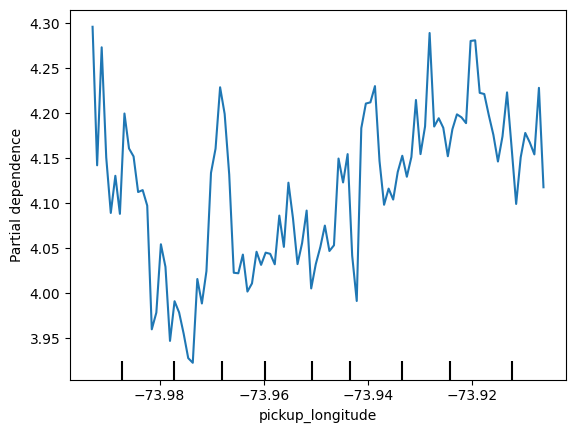

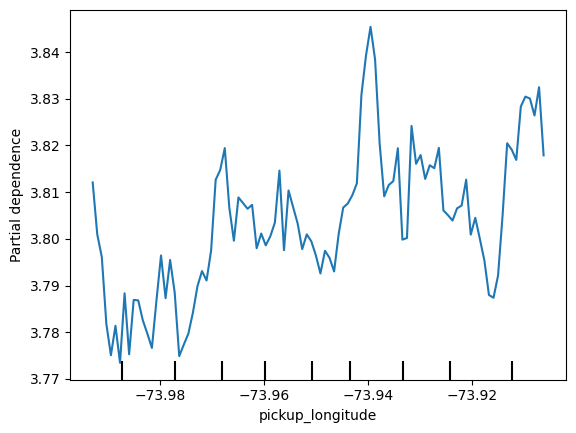

In [7]:
# This is the PDP for pickup_longitude without the absolute difference features. Included here to help compare it to the new PDP you create
feat_name = 'pickup_longitude'
PartialDependenceDisplay.from_estimator(first_model, val_X, [feat_name])
plt.show()

# Your code here
# create new features
data['abs_lon_change'] = abs(data.dropoff_longitude - data.pickup_longitude)
data['abs_lat_change'] = abs(data.dropoff_latitude - data.pickup_latitude)

features_2  = ['pickup_longitude',
               'pickup_latitude',
               'dropoff_longitude',
               'dropoff_latitude',
               'abs_lat_change',
               'abs_lon_change']

X = data[features_2]
new_train_X, new_val_X, new_train_y, new_val_y = train_test_split(X, y, random_state=1)
second_model = RandomForestRegressor(n_estimators=30, random_state=1).fit(new_train_X, new_train_y)

feat_name = 'pickup_longitude'
disp = PartialDependenceDisplay.from_estimator(second_model, new_val_X, [feat_name])
plt.show()


## Question 6
The code cell below does the following:

1. Creates two features, `X1` and `X2`, having random values in the range [-2, 2].
2. Creates a target variable `y`, which is always 1.
3. Trains a `RandomForestRegressor` model to predict `y` given `X1` and `X2`.
4. Creates a PDP plot for `X1` and a scatter plot of `X1` vs. `y`.

Do you have a prediction about what the PDP plot will look like? Run the cell to find out.

Modify the initialization of `y` so that our PDP plot has a positive slope in the range [-1,1], and a negative slope everywhere else. (Note: *you should only modify the creation of `y`, leaving `X1`, `X2`, and `my_model` unchanged.*)

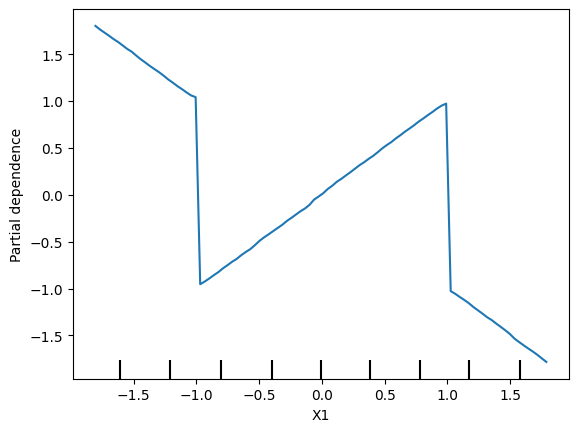

In [8]:
import numpy as np
from numpy.random import rand

n_samples = 20000

# Create array holding predictive feature
X1 = 4 * rand(n_samples) - 2
X2 = 4 * rand(n_samples) - 2

# Your code here
# Create y. you should have X1 and X2 in the expression for y
# y = np.ones(n_samples)
y = -2 * X1 * (X1<-1) + X1 - 2 * X1 * (X1>1) - X2

# create dataframe
my_df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})
predictors_df = my_df.drop(['y'], axis=1)

my_model = RandomForestRegressor(n_estimators=30, random_state=1).fit(predictors_df, my_df.y)
disp = PartialDependenceDisplay.from_estimator(my_model, predictors_df, ['X1'])
plt.show()


## Question 7
Create a dataset with 2 features and a target, such that the pdp of the first feature is flat, but its permutation importance is high.  We will use a RandomForest for the model.

*Note: You only need to supply the lines that create the variables X1, X2 and y. The code to build the model and calculate insights is provided*.

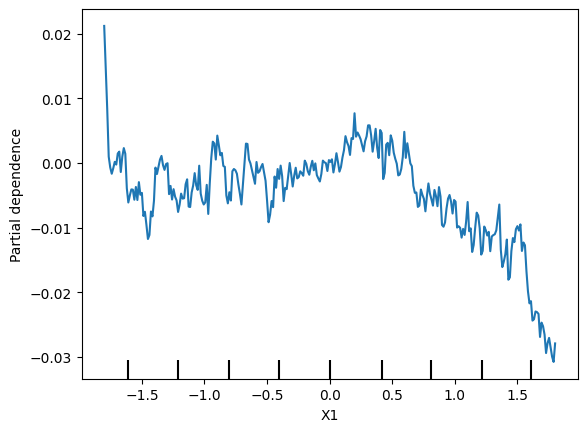

Weight,Feature
1.9989 ± 0.0395,X1
1.9874 ± 0.0618,X2


In [9]:
import eli5
from eli5.sklearn import PermutationImportance

n_samples = 20000

# Create array holding predictive feature
X1 = 4 * rand(n_samples) - 2
X2 = 4 * rand(n_samples) - 2
# Create y. you should have X in the expression for y
y = X1 * X2


# create dataframe because pdp_isolate expects a dataFrame as an argument
my_df = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})
predictors_df = my_df.drop(['y'], axis=1)

my_model = RandomForestRegressor(n_estimators=30, random_state=1).fit(predictors_df, my_df.y)


disp = PartialDependenceDisplay.from_estimator(my_model, predictors_df, ['X1'], grid_resolution=300)
plt.show()

perm = PermutationImportance(my_model).fit(predictors_df, my_df.y)


# show the weights for the permutation importance you just calculated
eli5.show_weights(perm, feature_names = ['X1', 'X2'])